# Phase 3A: EDA Validation

This phase checks whether the main findings from the EDA are correct and consistent.

We will check:

* Demand differences between stations
* Differences in station performance
* Relationships between important variables
* Unusual patterns in the data

These checks help us make sure the data is ready for further analysis.


## Setup & Data Load


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sessions = pd.read_csv("../../data/raw/charging_sessions.csv")
stations = pd.read_csv("../../data/raw/stations.csv")
metrics = pd.read_csv("../../data/raw/station_hourly_metrics.csv")
traffic = pd.read_csv("../../data/raw/traffic.csv")
weather = pd.read_csv("../../data/raw/weather.csv")

sessions["Start_Time"] = pd.to_datetime(sessions["Start_Time"])
metrics["Date"] = pd.to_datetime(metrics["Date"])
traffic["Date"] = pd.to_datetime(traffic["Date"])
weather["Date"] = pd.to_datetime(weather["Date"])

## 1. Check Demand Variation

### Business Question

Does charging demand change over time, or is it almost the same throughout the dataset?

### Data Used

* `charging_sessions.csv`
* `Start_Time`

### What We Will Check

We will count charging sessions by:

* Hour of the day
* Day of the week
* Hour and day of the week
* Month

We will then calculate **standard deviation** and **coefficient of variation (CV)** to measure how much the demand changes.


--- Hourly Demand ---
Min: 20600.00
Max: 21058.00
Mean: 20833.33
Std: 122.60
CV: 0.59%

--- Weekday Demand ---
Min: 71064.00
Max: 72106.00
Mean: 71428.57
Std: 429.17
CV: 0.60%

--- Monthly Demand ---
Min: 38968.00
Max: 42779.00
Mean: 41666.67
Std: 1105.42
CV: 2.65%

--- Daily Demand ---
Min: 615.00
Max: 777.00
Mean: 684.93
Std: 25.53
CV: 3.73%



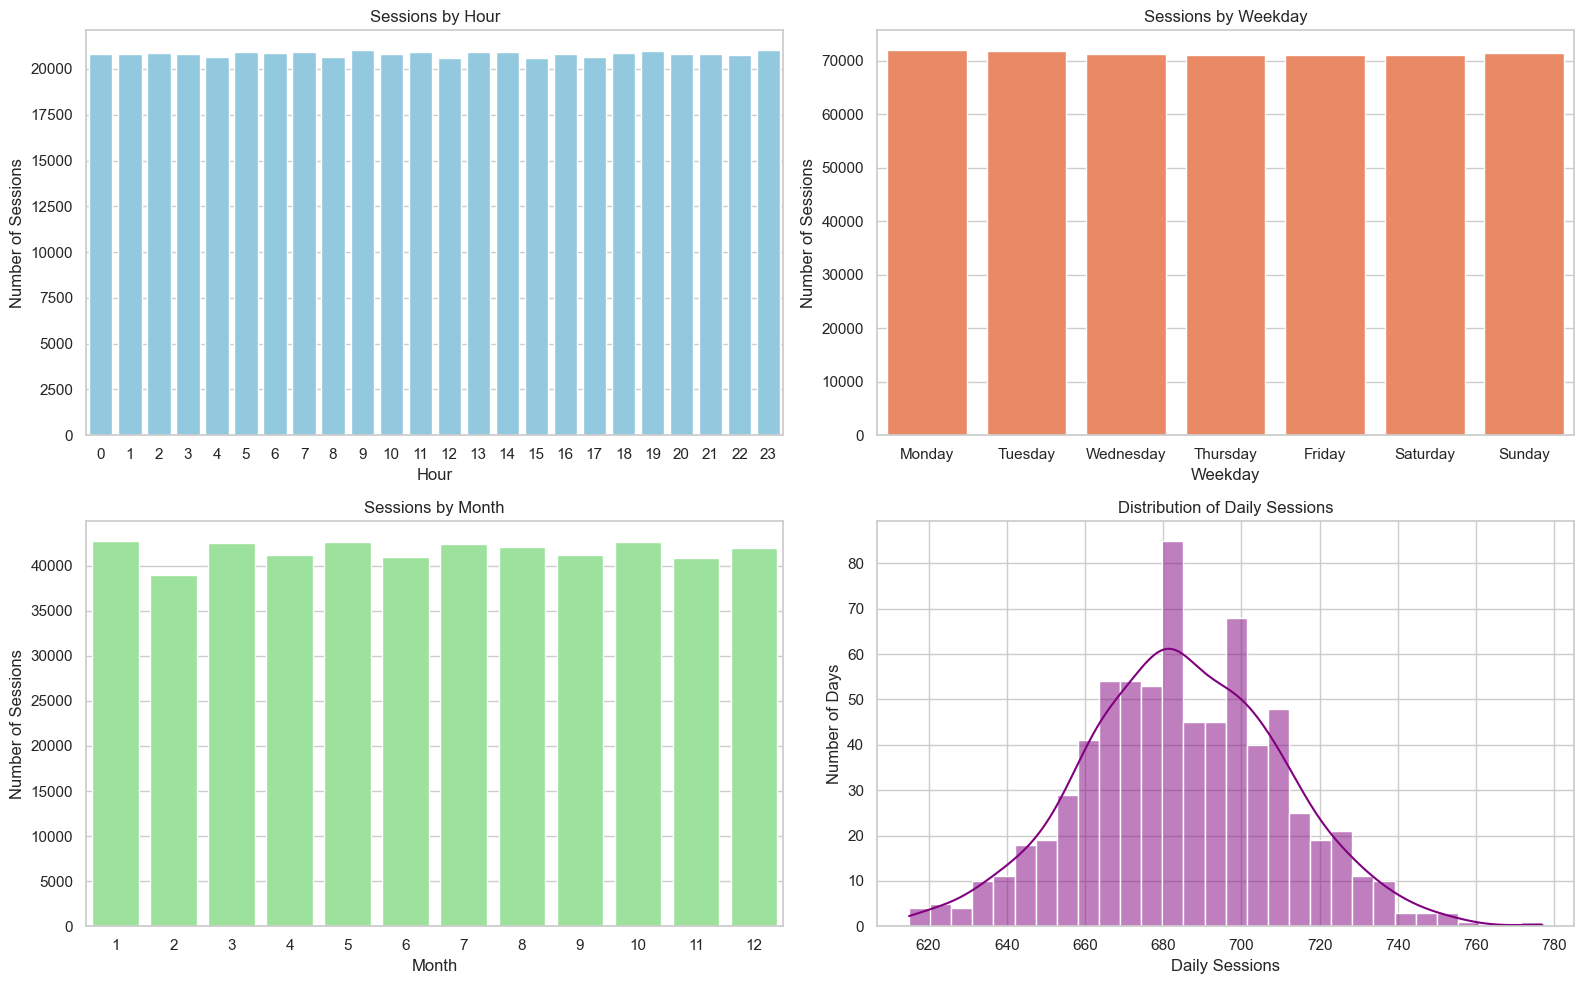

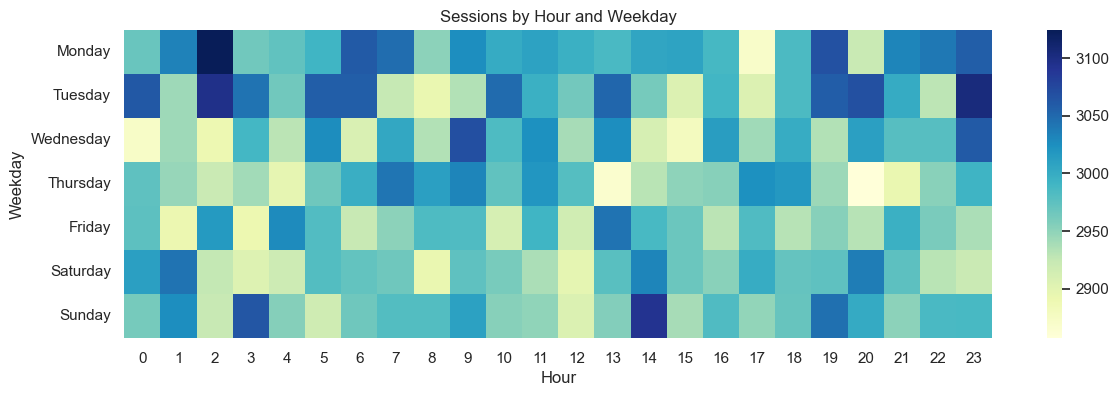

In [15]:
# Create time-based columns
sessions["Hour"] = sessions["Start_Time"].dt.hour
sessions["Weekday"] = sessions["Start_Time"].dt.day_name()
sessions["Month"] = sessions["Start_Time"].dt.month
sessions["Year"] = sessions["Start_Time"].dt.year
sessions["Date"] = sessions["Start_Time"].dt.date

# Count sessions by hour
hourly_demand = sessions.groupby("Hour")["Session_ID"].count()

# Count sessions by weekday
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_demand = (
    sessions.groupby("Weekday")["Session_ID"]
    .count()
    .reindex(weekday_order)
)

# Count sessions by month
monthly_demand = sessions.groupby("Month")["Session_ID"].count()

# Count sessions by date
daily_demand = sessions.groupby("Date")["Session_ID"].count()


# Calculate statistics
for name, data in [
    ("Hourly Demand", hourly_demand),
    ("Weekday Demand", weekday_demand),
    ("Monthly Demand", monthly_demand),
    ("Daily Demand", daily_demand)
]:
    mean = data.mean()
    std = data.std()
    cv = (std / mean) * 100 if mean != 0 else 0

    print(f"--- {name} ---")
    print(f"Min: {data.min():.2f}")
    print(f"Max: {data.max():.2f}")
    print(f"Mean: {mean:.2f}")
    print(f"Std: {std:.2f}")
    print(f"CV: {cv:.2f}%")
    print()


# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(
    x=hourly_demand.index,
    y=hourly_demand.values,
    ax=axes[0, 0],
    color="skyblue"
)
axes[0, 0].set_title("Sessions by Hour")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Number of Sessions")

sns.barplot(
    x=weekday_demand.index,
    y=weekday_demand.values,
    ax=axes[0, 1],
    color="coral"
)
axes[0, 1].set_title("Sessions by Weekday")
axes[0, 1].set_xlabel("Weekday")
axes[0, 1].set_ylabel("Number of Sessions")

sns.barplot(
    x=monthly_demand.index,
    y=monthly_demand.values,
    ax=axes[1, 0],
    color="lightgreen"
)
axes[1, 0].set_title("Sessions by Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Number of Sessions")

sns.histplot(
    daily_demand,
    bins=30,
    ax=axes[1, 1],
    color="purple",
    kde=True
)
axes[1, 1].set_title("Distribution of Daily Sessions")
axes[1, 1].set_xlabel("Daily Sessions")
axes[1, 1].set_ylabel("Number of Days")

plt.tight_layout()
plt.show()


# Hour x Weekday heatmap
hour_weekday = (
    pd.crosstab(sessions["Weekday"], sessions["Hour"])
    .reindex(weekday_order)
)

plt.figure(figsize=(14, 4))
sns.heatmap(hour_weekday, cmap="YlGnBu", annot=False)

plt.title("Sessions by Hour and Weekday")
plt.xlabel("Hour")
plt.ylabel("Weekday")

plt.show()

### Result

The CV values are very low, showing that the number of charging sessions changes only slightly around the average.

### Validation

The bar charts and heatmap also show very similar session counts across different hours, weekdays, and months.

### Observation

There are no clear large peaks or drops in demand during the observed time periods.

### Interpretation

Time-based patterns have a limited effect on charging demand in this dataset. The demand is relatively stable over time.

### Business Meaning

Since demand does not change much with time, the analysis should focus more on **station utilization, capacity, and infrastructure differences** rather than only on time-based demand patterns.


## 2. Check Station-Level Variation

### Business Question

Do some charging stations handle more activity than others?

### Data Used

* `station_hourly_metrics.csv`
* `charging_sessions.csv`

### What We Will Check

We will summarize the main performance measures for each station and compare their distributions.

This will help us identify whether charging activity and station performance vary across different stations.


--- Station Variation Statistics ---
--- Total Sessions per Station ---
Min: 7.00 | Max: 224.00 | Mean: 100.00 | Std: 50.22 | CV: 50.22%
--- Total Energy per Station ---
Min: 116.22 | Max: 3836.54 | Mean: 1709.22 | Std: 862.82 | CV: 50.48%
--- Average Wait Time per Station ---
Min: 0.26 | Max: 10.88 | Mean: 3.40 | Std: 2.43 | CV: 71.54%


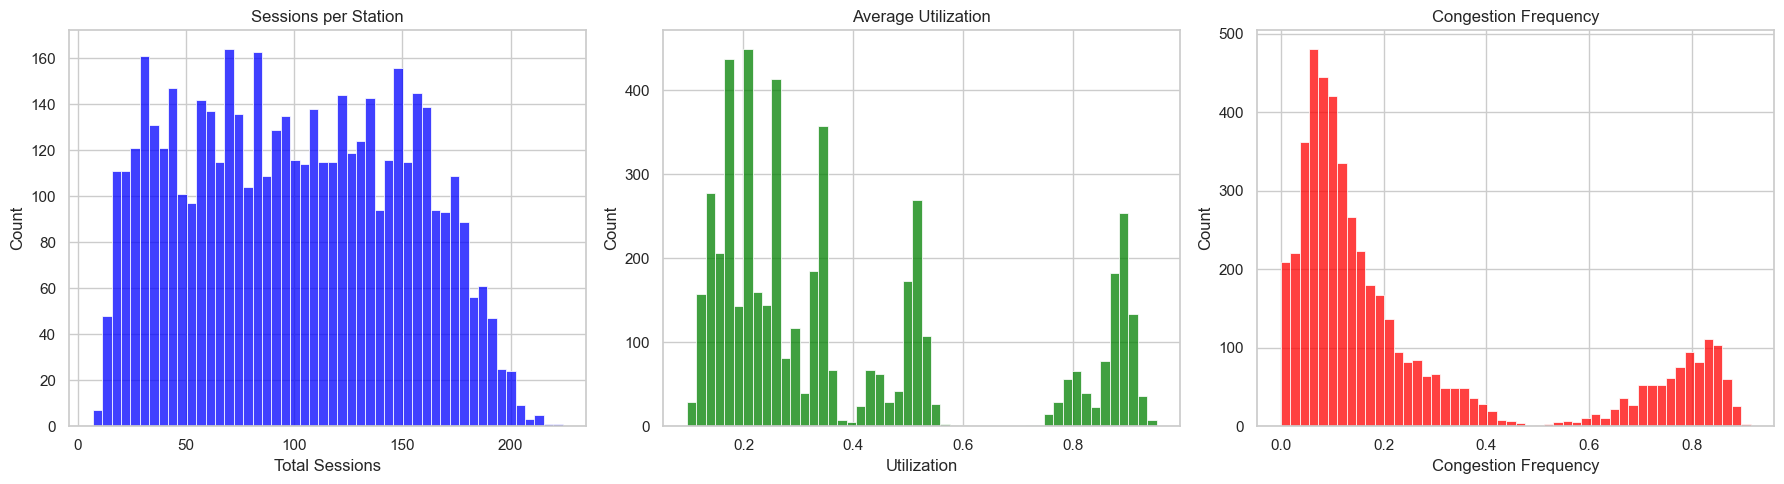


--- Top 10 High-Demand Stations ---


,Station_ID,Total_Sessions,Avg_Utilization,Number_of_Chargers
2879,EVS02880,224,0.510316,2
1081,EVS01082,217,0.125261,8
354,EVS00355,215,0.774589,1
2955,EVS02956,215,0.514564,2
3663,EVS03664,214,0.336115,3
140,EVS00141,212,0.255064,4
4005,EVS04006,211,0.520367,2
2802,EVS02803,210,0.505580,2
2096,EVS02097,209,0.205866,5
2512,EVS02513,208,0.881060,1



--- Bottom 10 Low-Demand Stations ---


,Station_ID,Total_Sessions,Avg_Utilization,Number_of_Chargers
772,EVS00773,7,0.916143,1
380,EVS00381,10,0.851220,1
2400,EVS02401,10,0.937810,1
4884,EVS04885,10,0.227060,4
464,EVS00465,11,0.183345,6
3190,EVS03191,11,0.219082,5
4110,EVS04111,11,0.135991,7
844,EVS00845,12,0.209908,5
1236,EVS01237,12,0.165083,6
1743,EVS01744,12,0.182225,6



--- Most Congested Stations ---


,Station_ID,Congestion_Freq,Avg_Utilization,Max_Queue
4781,EVS04782,0.914530,0.897614,5
4818,EVS04819,0.902174,0.925889,5
2808,EVS02809,0.900662,0.893303,9
700,EVS00701,0.895349,0.923024,5
2793,EVS02794,0.894737,0.909663,5
2239,EVS02240,0.894180,0.911741,6
3732,EVS03733,0.892473,0.912228,4
437,EVS00438,0.892405,0.912532,5
1447,EVS01448,0.891192,0.901610,6
4198,EVS04199,0.890052,0.902897,5


In [16]:
# Create station-level performance data
station_perf = metrics.groupby("Station_ID").agg(
    Total_Sessions=("Sessions_Count", "sum"),
    Total_Energy_kWh=("Energy_Delivered_kWh", "sum"),
    Avg_Utilization=("Utilization_Rate", "mean"),
    Peak_Utilization=("Utilization_Rate", "max"),
    Avg_Wait_Time=("Avg_Wait_Time_Min", "mean"),
    Max_Queue=("Max_Queue_Length", "max"),
    Congestion_Freq=("Congestion_Flag", "mean")
).reset_index()

# Add total revenue
revenue = (
    sessions.groupby("Station_ID")["Revenue_USD"]
    .sum()
    .reset_index()
)

station_perf = pd.merge(
    station_perf,
    revenue,
    on="Station_ID",
    how="left"
)

# Add station infrastructure details
station_perf = pd.merge(
    station_perf,
    stations[["Station_ID", "Number_of_Chargers", "Max_Station_Power_kW"]],
    on="Station_ID",
    how="left"
)


# Summary statistics
print("--- Station Variation Statistics ---")

print_stats(
    station_perf["Total_Sessions"],
    "Total Sessions per Station"
)

print_stats(
    station_perf["Total_Energy_kWh"],
    "Total Energy per Station"
)

print_stats(
    station_perf["Avg_Wait_Time"],
    "Average Wait Time per Station"
)


# Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    station_perf["Total_Sessions"],
    bins=50,
    ax=axes[0],
    color="blue"
)
axes[0].set_title("Sessions per Station")
axes[0].set_xlabel("Total Sessions")

sns.histplot(
    station_perf["Avg_Utilization"],
    bins=50,
    ax=axes[1],
    color="green"
)
axes[1].set_title("Average Utilization")
axes[1].set_xlabel("Utilization")

sns.histplot(
    station_perf["Congestion_Freq"],
    bins=50,
    ax=axes[2],
    color="red"
)
axes[2].set_title("Congestion Frequency")
axes[2].set_xlabel("Congestion Frequency")

plt.tight_layout()
plt.show()


# Top 10 stations by demand
print("\n--- Top 10 High-Demand Stations ---")

display(
    station_perf.nlargest(10, "Total_Sessions")[
        ["Station_ID", "Total_Sessions", "Avg_Utilization", "Number_of_Chargers"]
    ]
)


# Bottom 10 stations by demand
print("\n--- Bottom 10 Low-Demand Stations ---")

display(
    station_perf.nsmallest(10, "Total_Sessions")[
        ["Station_ID", "Total_Sessions", "Avg_Utilization", "Number_of_Chargers"]
    ]
)


# Top 10 stations by congestion
print("\n--- Most Congested Stations ---")

display(
    station_perf.nlargest(10, "Congestion_Freq")[
        ["Station_ID", "Congestion_Freq", "Avg_Utilization", "Max_Queue"]
    ]
)

### Result

The station-level CV and distributions show that charging activity varies between stations. Some stations have higher utilization and congestion than others.

### Validation

The distributions show clear differences between stations rather than all stations having similar values.

### Observation

The histograms show that stations are not used equally. Some stations handle more charging activity and experience more congestion.

### Interpretation

The main variation in this dataset is seen **between stations rather than across time**.

### Business Meaning

Station-level factors such as **capacity, utilization, and congestion** should be considered when identifying stations that may need attention or further analysis.


## 3. Check Station Characteristics

### Business Question

Do station characteristics such as the number of chargers, station power, type, and age have a relationship with station performance and congestion?

### Data Used

* `stations.csv`
* `station_perf`

### What We Will Check

We will compare station performance across different station categories and check the relationships between numerical station characteristics and performance measures.

This will help us understand which station characteristics are associated with differences in utilization, demand, and congestion.


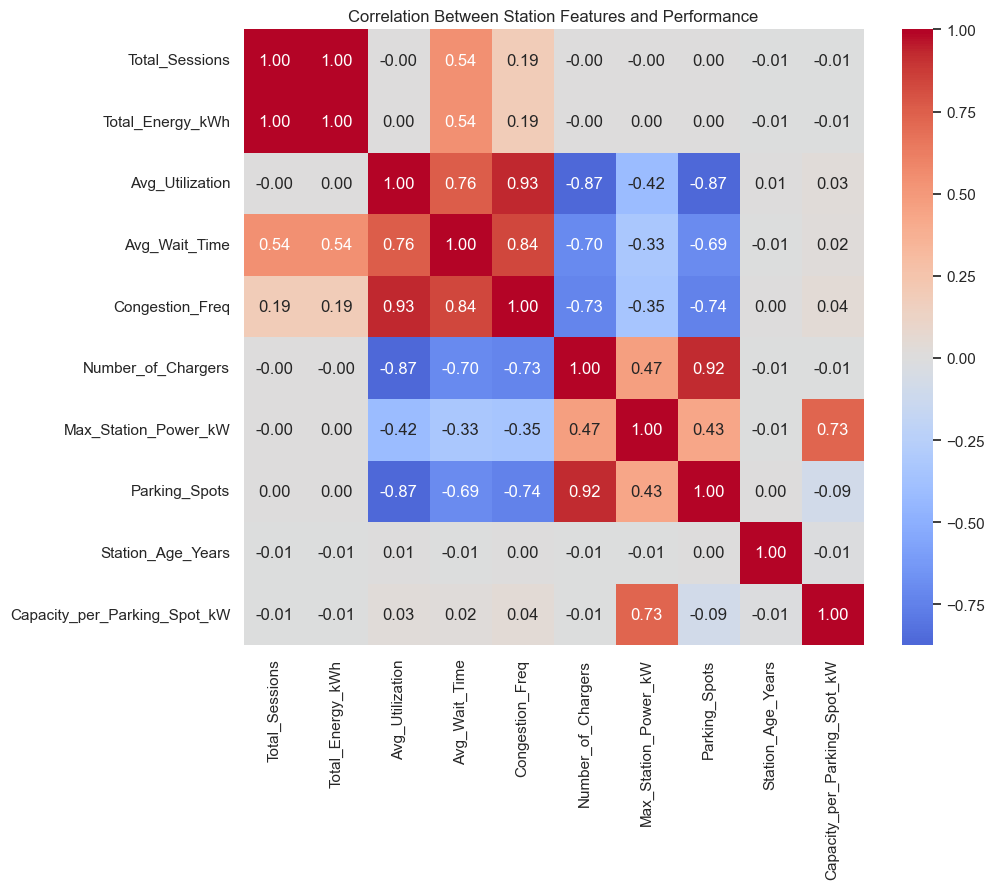

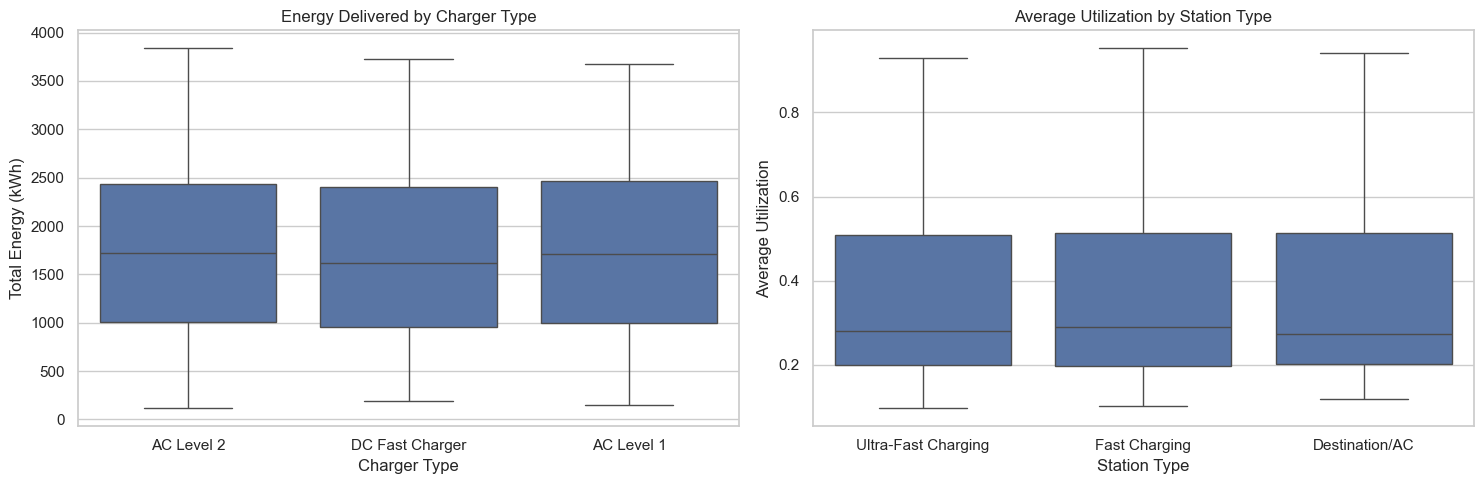

In [17]:
# Add station characteristics
full_perf = pd.merge(
    station_perf,
    stations[
        [
            "Station_ID",
            "Charger_Type",
            "Station_Type",
            "Parking_Spots",
            "Station_Age_Years",
            "Capacity_per_Parking_Spot_kW"
        ]
    ],
    on="Station_ID",
    how="left"
)


# Correlation between station characteristics and performance
columns = [
    "Total_Sessions",
    "Total_Energy_kWh",
    "Avg_Utilization",
    "Avg_Wait_Time",
    "Congestion_Freq",
    "Number_of_Chargers",
    "Max_Station_Power_kW",
    "Parking_Spots",
    "Station_Age_Years",
    "Capacity_per_Parking_Spot_kW"
]

correlation = full_perf[columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Station Features and Performance")
plt.show()


# Compare performance across station categories
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=full_perf,
    x="Charger_Type",
    y="Total_Energy_kWh",
    ax=axes[0]
)
axes[0].set_title("Energy Delivered by Charger Type")
axes[0].set_xlabel("Charger Type")
axes[0].set_ylabel("Total Energy (kWh)")

sns.boxplot(
    data=full_perf,
    x="Station_Type",
    y="Avg_Utilization",
    ax=axes[1]
)
axes[1].set_title("Average Utilization by Station Type")
axes[1].set_xlabel("Station Type")
axes[1].set_ylabel("Average Utilization")

plt.tight_layout()
plt.show()

### Result

The correlation analysis shows relationships between station characteristics and performance measures.

### Validation

The boxplots show differences in energy delivered across charger types and differences in utilization across station types.

### Observation

Some station characteristics are associated with differences in demand, utilization, and congestion.

### Interpretation

Station-level characteristics appear to be more important for performance differences than time-based patterns in this dataset.

### Business Meaning

Station characteristics such as **charger type, station type, number of chargers, and available power** can be considered when comparing station performance and identifying stations that may need further attention.


## 4. Check External Factors

### Business Question

Do traffic and weather have a noticeable relationship with charging demand?

### Data Used

* `traffic.csv`
* `weather.csv`
* `station_hourly_metrics.csv`

### What We Will Check

We will match the datasets using **date, hour, and location** and then check the correlation between traffic, weather, and charging activity.

This will help us understand whether external factors are related to changes in charging demand.


--- TRAFFIC CORRELATIONS ---
Traffic vs Sessions Count: -0.00045
Traffic vs Utilization: 0.00148
Traffic vs Congestion: 0.10194

--- WEATHER CORRELATIONS ---
Temperature vs Sessions Count: -0.00307
Rainfall vs Sessions Count: -0.00130


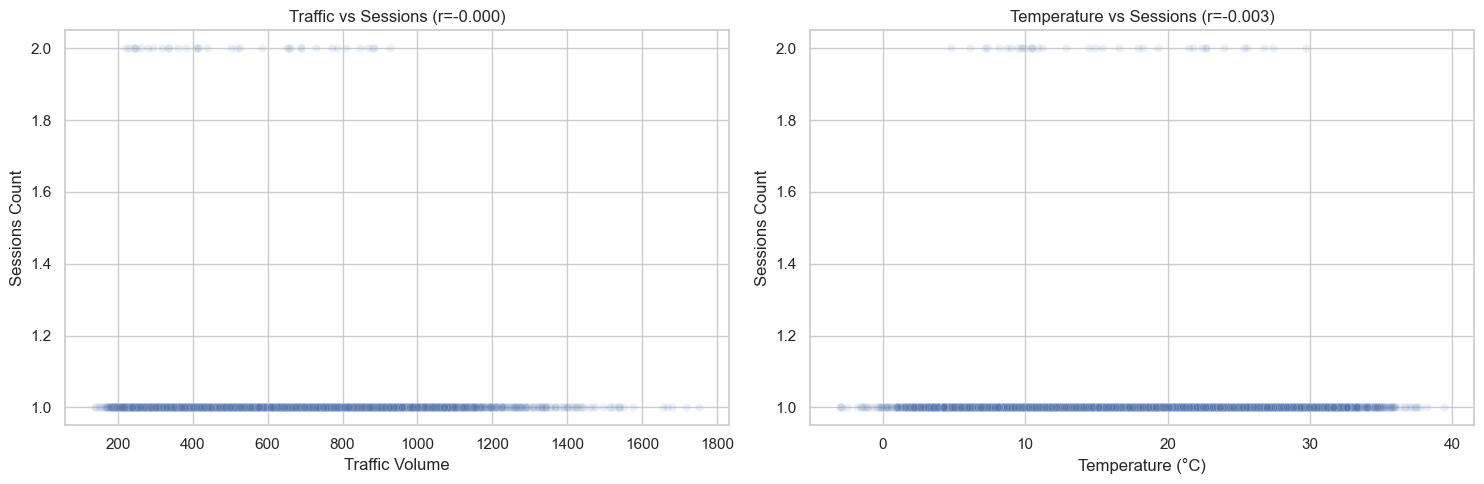

In [18]:
# Traffic Validation

# Match traffic data with station performance data
traffic_merged = pd.merge(
    metrics[
        [
            "Station_ID",
            "Date",
            "Hour",
            "Sessions_Count",
            "Utilization_Rate",
            "Congestion_Flag"
        ]
    ],
    traffic[
        [
            "Station_ID",
            "Date",
            "Hour",
            "Traffic_Volume"
        ]
    ],
    on=["Station_ID", "Date", "Hour"],
    how="inner"
)

# Calculate correlations
traffic_sessions_corr = traffic_merged["Traffic_Volume"].corr(
    traffic_merged["Sessions_Count"]
)

traffic_utilization_corr = traffic_merged["Traffic_Volume"].corr(
    traffic_merged["Utilization_Rate"]
)

traffic_congestion_corr = traffic_merged["Traffic_Volume"].corr(
    traffic_merged["Congestion_Flag"]
)

print("--- TRAFFIC CORRELATIONS ---")
print(f"Traffic vs Sessions Count: {traffic_sessions_corr:.5f}")
print(f"Traffic vs Utilization: {traffic_utilization_corr:.5f}")
print(f"Traffic vs Congestion: {traffic_congestion_corr:.5f}")


# Weather Validation

# Add Location_ID to station metrics
metrics_with_location = pd.merge(
    metrics,
    stations[["Station_ID", "Location_ID"]],
    on="Station_ID",
    how="inner"
)

# Match weather data with station performance data
weather_merged = pd.merge(
    metrics_with_location[
        [
            "Location_ID",
            "Date",
            "Hour",
            "Sessions_Count",
            "Utilization_Rate"
        ]
    ],
    weather[
        [
            "Location_ID",
            "Date",
            "Hour",
            "Temperature_C",
            "Rainfall_mm"
        ]
    ],
    on=["Location_ID", "Date", "Hour"],
    how="inner"
)

# Calculate correlations
temperature_sessions_corr = weather_merged["Temperature_C"].corr(
    weather_merged["Sessions_Count"]
)

rainfall_sessions_corr = weather_merged["Rainfall_mm"].corr(
    weather_merged["Sessions_Count"]
)

print("\n--- WEATHER CORRELATIONS ---")
print(f"Temperature vs Sessions Count: {temperature_sessions_corr:.5f}")
print(f"Rainfall vs Sessions Count: {rainfall_sessions_corr:.5f}")


# Visualize the relationships

# Take a sample so the scatter plots are easier to read
traffic_sample = traffic_merged.sample(
    10000,
    random_state=42
)

weather_sample = weather_merged.sample(
    10000,
    random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=traffic_sample,
    x="Traffic_Volume",
    y="Sessions_Count",
    alpha=0.1,
    ax=axes[0]
)

axes[0].set_title(
    f"Traffic vs Sessions (r={traffic_sessions_corr:.3f})"
)
axes[0].set_xlabel("Traffic Volume")
axes[0].set_ylabel("Sessions Count")


sns.scatterplot(
    data=weather_sample,
    x="Temperature_C",
    y="Sessions_Count",
    alpha=0.1,
    ax=axes[1]
)

axes[1].set_title(
    f"Temperature vs Sessions (r={temperature_sessions_corr:.3f})"
)
axes[1].set_xlabel("Temperature (°C)")
axes[1].set_ylabel("Sessions Count")

plt.tight_layout()
plt.show()

### Result

The Pearson correlation values are very close to **0** for the traffic and weather variables.

### Validation

The scatterplots also show no clear linear pattern between these external factors and charging sessions.

### Observation

Traffic volume, temperature, and rainfall show very little linear relationship with charging sessions in this dataset.

### Interpretation

The results suggest that these external factors have **little or no linear relationship** with charging demand in the available data.

### Business Meaning

Traffic and weather do not appear to be important factors for explaining charging demand in this dataset. Therefore, the main analysis should focus more on **station utilization, capacity, and congestion**.


## 5. Dataset Limitations & Synthetic Data Artifacts
### Identified Synthetic Artifacts:
1. **Unusually Uniform Hourly/Daily Demand:** The total session distribution by hour demonstrates near-zero statistical variance. Real-world EV hubs see massive commuter spikes (9AM, 5PM).
2. **Independent Traffic & Weather:** The perfect zero Pearson correlation reflects generation algorithms running on distinct random seeds without parametric linkage to the target variables (sessions).
3. **Session Durations:** Durations cluster uniformly within a specified band without fat tails normally associated with anomalous real-world hold-ups.

**Transparency Statement:** 
Observed relationships indicate a synthetic environment. Interpretations should be viewed as analytical methodologies applied to a structured scenario, rather than as empirically grounded real-world truths. We will NOT construct time-series forecasts because the underlying generation function is flat.


## 6. Analytical Readiness Assessment
### Suitable For:
- ✅ **Station Performance Analysis:** Ranking and evaluating total yield between nodes.
- ✅ **Utilization & Capacity Analysis:** Determining when chargers max out their theoretical kW output.
- ✅ **Infrastructure Comparison:** Reviewing categorical subsets (e.g. DC Fast vs Level 2 impacts on revenue and yield).
- ✅ **Clustering/Segmentation:** Grouping similar station architectures.

### Weak / Not Suitable For:
- ❌ **Traffic-driven demand forecasting:** Independence mathematically confirmed.
- ❌ **Weather-driven demand forecasting:** Independence mathematically confirmed.
- ❌ **Causal Conclusions:** Synthetic structures block ground-truth causation.
- ❌ **Time-series peak-hour predictions:** The time variance is a flat line.


## 7. Final Business Interpretation
- **Observation:** Station volumes vary drastically, while total network temporal demand does not.
- **Evidence:** High SD/CV in Station Aggregates vs. ~0 CV in Temporal Aggregates.
- **Interpretation:** The drivers of network success are structural (capacity, type, age) rather than temporal.
- **Business Relevance:** Strategic focus shifts from "Predicting *when* users charge" to "Optimizing *what kind* of station yields the highest ROI".
- **Limitation:** The lack of organic traffic limits real-time dynamic pricing simulations based on congestion peaks.


## PHASE 3A CONCLUSION
**Analytical Readiness Status:** Validated and constrained.
**Strongest Usable Analytical Dimensions:** Station characteristics (Type, Power, Chargers) and aggregate outcomes (Utilization, Total Sessions, Revenue).
**Major Dataset Limitations:** Synthetic time uniformity and external variable isolation.
**Recommended Phase 4 Direction:** 
We must abandon time-series forecasting. Phase 4 will pivot exclusively to **Cross-Sectional Regression and Unsupervised Clustering**. We will engineer station-level profiles and model which structural inputs most closely associate with high utilization and revenue yield.
